# SSD-MobileNetV2: OpenVINO Detection

**Flow:** Download model -> select device & precision -> infer -> charts (latency, model size)

**Model:** ssdlite_mobilenet_v2 (OMZ) - COCO 91 classes, person (1) + car (3)

## 1. Install dependencies (run once)

In [1]:
!pip install -q openvino openvino-dev opencv-python matplotlib tensorflow gradio ipywidgets

## 2. Imports and config

In [2]:
import glob
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import openvino as ov
from utils import (
    download_ssdlite_mobilenet_v2,
    load_compiled_model,
    get_available_devices,
    preprocess_ssdlite,
    run_detection_ssdlite,
    draw_boxes,
    benchmark_latency_ms,
    check_device_latency,
    plot_ssdlite_fp32_fp16_charts,
)

MODEL_DIR = "models_test"
IMAGE_PATH = "media/sample_image-1.jpg"
TARGET_CLASSES = (1, 3)  # person, car
THRESH = 0.3

## 3. Download and convert model (run once)

Requires TensorFlow for conversion. ssdlite_mobilenet_v2: COCO 91 classes, 300x300 input.

In [3]:
download_ssdlite_mobilenet_v2(MODEL_DIR)

'models_test'

## 4. Select device & precision, load model

In [4]:
import ipywidgets as widgets
from IPython.display import display

devices = get_available_devices()
default_dev = "CPU" if "CPU" in devices else (devices[0] if devices else "CPU")
device_dropdown = widgets.Dropdown(options=devices, value=default_dev, description="Device:")
precision_dropdown = widgets.Dropdown(options=["FP32", "FP16"], value="FP32", description="Precision:")
load_out = widgets.Output()

def _load_ssdlite(*args):
    global compiled, xml_path, input_shape
    with load_out:
        load_out.clear_output(wait=True)
        compiled, xml_path = load_compiled_model(MODEL_DIR, precision_dropdown.value, device_dropdown.value)
        input_shape = compiled.input(0).shape
        print(f"Loaded {precision_dropdown.value} on {device_dropdown.value} | Input: {input_shape}")

device_dropdown.observe(_load_ssdlite, names="value")
precision_dropdown.observe(_load_ssdlite, names="value")
display(widgets.HBox([device_dropdown, precision_dropdown]))
display(load_out)
_load_ssdlite()

Output()

## 5. Inference (OpenVINO flow)

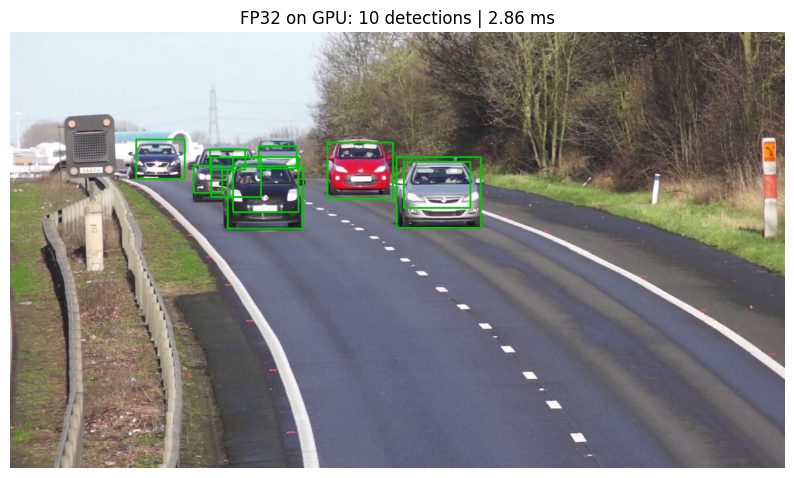

In [9]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

boxes, labels, input_tensor = run_detection_ssdlite(
    compiled, image, input_shape, target_classes=TARGET_CLASSES, thresh=THRESH
)
result_img = draw_boxes(image, boxes)
latency_ms = benchmark_latency_ms(compiled, input_tensor, num_iter=50)
check_device_latency(device_dropdown.value, latency_ms, "ssdlite")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{precision_dropdown.value} on {device_dropdown.value}: {len(boxes)} detections | {latency_ms:.2f} ms")
plt.show()

## 6. Charts: Latency and model size (FP32 vs FP16)

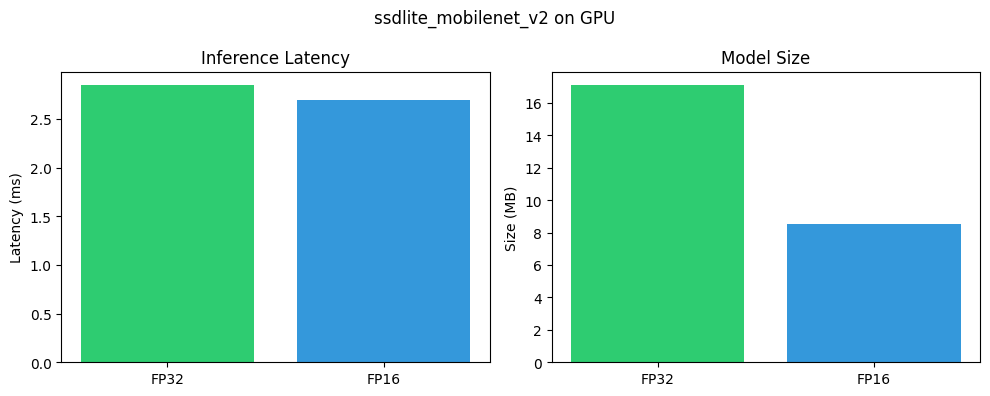

In [10]:
fig = plot_ssdlite_fp32_fp16_charts(MODEL_DIR, device_dropdown.value, IMAGE_PATH, TARGET_CLASSES, THRESH)
plt.show()

## 7. Launch Gradio app

In [7]:
from app_gradio import create_demo
demo = create_demo(MODEL_DIR)
demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


---

In [8]:
#demo.close()